<a href="https://colab.research.google.com/github/Dathu-03184/DL_Lab-Programs/blob/main/18%20program.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Training with batch_size=16, optimizer=adam, activation=relu, learning_rate=0.001
Test Accuracy: 1.000

Training with batch_size=16, optimizer=adam, activation=relu, learning_rate=0.01
Test Accuracy: 1.000

Training with batch_size=16, optimizer=adam, activation=tanh, learning_rate=0.001
Test Accuracy: 1.000

Training with batch_size=16, optimizer=adam, activation=tanh, learning_rate=0.01
Test Accuracy: 0.520

Training with batch_size=16, optimizer=sgd, activation=relu, learning_rate=0.001
Test Accuracy: 1.000

Training with batch_size=16, optimizer=sgd, activation=relu, learning_rate=0.01
Test Accuracy: 1.000

Training with batch_size=16, optimizer=sgd, activation=tanh, learning_rate=0.001
Test Accuracy: 1.000

Training with batch_size=16, optimizer=sgd, activation=tanh, learning_rate=0.01
Test Accuracy: 1.000

Training with batch_size=32, optimizer=adam, activation=relu, learning_rate=0.001
Test Accuracy: 1.000

Training with batch_size=32, optimizer=adam, activation=relu, learning_

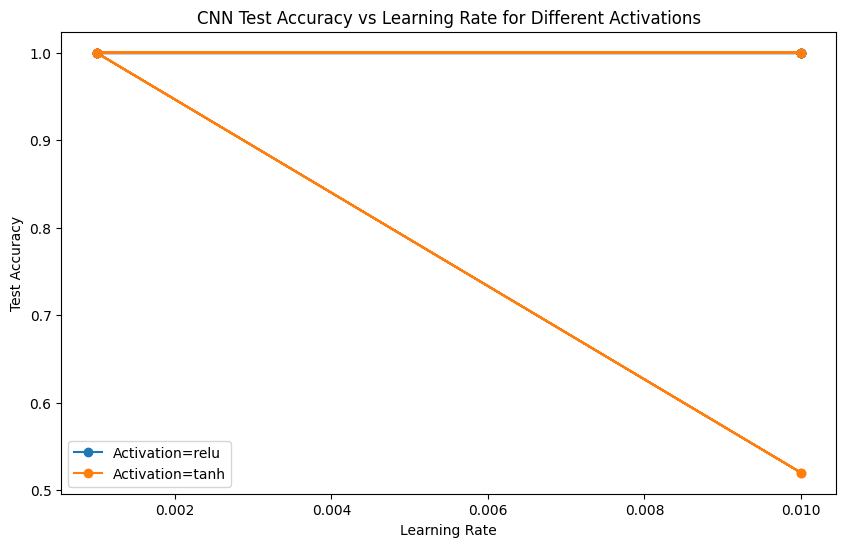

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import pandas as pd

# 1️⃣ Generate synthetic binary image dataset (64x64 grayscale)
num_samples = 1000
img_height, img_width = 64, 64

# Class 0: random noise
X0 = np.random.rand(num_samples//2, img_height, img_width, 1)
y0 = np.zeros(num_samples//2)

# Class 1: random noise with central square pattern
X1 = np.random.rand(num_samples//2, img_height, img_width, 1)
X1[:, 16:48, 16:48, 0] += 0.5  # Add pattern
y1 = np.ones(num_samples//2)

# Combine dataset
X = np.concatenate([X0, X1], axis=0)
y = np.concatenate([y0, y1], axis=0)

# Normalize images
X = X / np.max(X)

# Convert labels to categorical (Softmax)
y_cat = to_categorical(y, num_classes=2)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y_cat, test_size=0.2, random_state=42)

# 2️⃣ Define hyperparameters to test
batch_sizes = [16, 32]
optimizers = ['adam', 'sgd']
activations = ['relu', 'tanh']
learning_rates = [0.001, 0.01]

# 3️⃣ Function to build CNN with variable activation
def build_cnn(activation_func):
    model = Sequential([
        Conv2D(16, (3,3), activation=activation_func, input_shape=(img_height, img_width,1)),
        MaxPooling2D((2,2)),
        Conv2D(32, (3,3), activation=activation_func),
        MaxPooling2D((2,2)),
        Flatten(),
        Dense(64, activation=activation_func),
        Dense(2, activation='softmax')
    ])
    return model

# 4️⃣ Iterate over hyperparameter combinations
results = []
for batch_size in batch_sizes:
    for opt_name in optimizers:
        for act in activations:
            for lr in learning_rates:
                print(f"\nTraining with batch_size={batch_size}, optimizer={opt_name}, activation={act}, learning_rate={lr}")

                # Build model
                model = build_cnn(act)

                # Choose optimizer with learning rate
                if opt_name == 'adam':
                    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
                elif opt_name == 'sgd':
                    optimizer = tf.keras.optimizers.SGD(learning_rate=lr)

                # Compile model
                model.compile(optimizer=optimizer,
                              loss='categorical_crossentropy',
                              metrics=['accuracy'])

                # Train model
                history = model.fit(X_train, y_train, epochs=10, batch_size=batch_size, verbose=0, validation_split=0.2)

                # Evaluate on test set
                loss, acc = model.evaluate(X_test, y_test, verbose=0)
                print(f"Test Accuracy: {acc:.3f}")

                results.append({
                    'batch_size': batch_size,
                    'optimizer': opt_name,
                    'activation': act,
                    'learning_rate': lr,
                    'test_accuracy': acc
                })

# 5️⃣ Convert results to DataFrame for visualization
results_df = pd.DataFrame(results)
print("\nAll Results:")
print(results_df)

# 6️⃣ Visualization: Test Accuracy vs Learning Rate for each Activation
plt.figure(figsize=(10,6))
for act in activations:
    subset = results_df[results_df['activation'] == act]
    plt.plot(subset['learning_rate'], subset['test_accuracy'], marker='o', label=f'Activation={act}')
plt.xlabel('Learning Rate')
plt.ylabel('Test Accuracy')
plt.title('CNN Test Accuracy vs Learning Rate for Different Activations')
plt.legend()
plt.show()
